# 04 — LightGBM Scorecard: xBooster маягийн PDO Scoring

**Санаа.** 02-ын scorecard ил тод ч шугаман. Энд хүчирхэг **LightGBM** (gradient
boosting) ашиглаж, дараа нь түүний гаралтыг банкны салбарын стандарт **PDO
(Points to Double the Odds)** томьёогоор 350–850 оноо болгон хувиргана. Ингэснээр
нарийн моделийн нарийвчлал + scorecard-ын ойлгомжтой оноог хослуулна.

**PDO гэж юу вэ?** "Эрсдэлийн магадлал хоёр дахин буурахад оноо хэдээр нэмэгдэх"-ийг
тогтоодог тохиргоо (энд PDO=50). Тиймээс оноо нь логистик утгад шугаман
хамааралтай, тайлбарлахад хялбар.

**SHAP** ашиглан аль хувьсагч таамаглалд хэр нөлөөлснийг харуулна.

**Популяци:** `both + zms_only + hur_only` (neither хасагдсан), нэг нэгдсэн модель.

In [1]:
%matplotlib inline
import sys
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import lightgbm as lgb
from lightgbm import LGBMClassifier
import joblib, os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split

import config, features, metrics

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
os.makedirs(config.MODEL_DIR, exist_ok=True)

TARGETS = config.TARGETS
SEED = config.SEED
PDO, TARGET_POINTS, TARGET_ODDS = config.PDO, config.TARGET_POINTS, config.TARGET_ODDS

def safe_name(t):
    return t.replace('+','plus').replace('_','').replace(' ','').replace('-','')

df = config.load_data()
df = features.engineer_features(df)
df['segment'] = df.apply(config.assign_segment, axis=1)
print(f'Loaded: {df.shape}')
print(f'haszms=1: {(df["haszms"]==1).sum():,}  | neither excluded: {(df["haszms"]==0).sum():,}')
for t in TARGETS:
    print(f'  {t}: bad_rate={df[t].mean():.3f}')

[load_data] neither хасав: 57,127 → 39,242 (17,885 мөр хасагдсан)


Loaded: (39242, 108)
haszms=1: 39,136  | neither excluded: 106
  30: bad_rate=0.129
  before_first_close_30+: bad_rate=0.042


## 1. Combined LightGBM сургах (бүх популяци)

High-cardinality `city_name`-ийн оронд **`zone` (14 анги)**-г train дээр fit хийсэн **target encoding**-оор тоон болгоно (leakage-гүй). Дутуу утгыг -999-ээр дүүргэнэ. `class_weight='balanced'`.

**Хувьсагч сонголт:** ~100 хувьсагчийг IV≥0.02, |r|≤0.75-аар цөөлж, сонгосон олонлогоор сургана.

In [2]:
combined_df = df.copy()   # neither аль хэдийн хасагдсан (both + zms_only + hur_only)
print(f'Population: {len(combined_df):,} rows')

ALL_TARGET_COLS = set(['15+','30','before_first_close_30+']) & set(df.columns)
DROP_BASE = {'city_name','region','zone','haszms','hashur','segment','age_grp','is_test'} \
            | set(config.ID_COLS) | ALL_TARGET_COLS

IS_TEST = config.make_split(combined_df)   # нийтлэг хуваалт

# ── Хувьсагч сонголт: IV + корреляц (ЗӨВХӨН train дээр) ──
import feature_selection as fs, pandas as pd
feats0 = [c for c in combined_df.columns if c not in DROP_BASE]
num_all = combined_df[feats0].select_dtypes(include='number').columns.tolist()
df_tr0 = combined_df[~IS_TEST]
SEL_NUM, IV_NUM = fs.select_features(df_tr0, num_all, config.PRIMARY_TARGET,
                                     categorical=(), iv_threshold=0.02, corr_threshold=0.75)
print(f"Бүх numeric: {len(num_all)}  →  IV+корреляц шүүлтийн дараа: {len(SEL_NUM)}")

all_res = {}
for target in TARGETS:
    print(f'\n{"="*55}\nTarget: {target}  bad_rate={combined_df[target].mean():.3f}')
    num_feats = SEL_NUM            # цөөлсөн олонлогоор сургана

    train_idx = combined_df.index[~IS_TEST]
    test_idx  = combined_df.index[IS_TEST]
    y_tr = combined_df.loc[train_idx, target].values
    y_te = combined_df.loc[test_idx,  target].values

    X_tr = combined_df.loc[train_idx, num_feats].copy().fillna(-999)
    X_te = combined_df.loc[test_idx,  num_feats].copy().fillna(-999)

    zone_tr = combined_df.loc[train_idx,'zone'].astype(str)
    zone_te = combined_df.loc[test_idx,'zone'].astype(str)
    gmean = y_tr.mean()
    stats = pd.DataFrame({'k':zone_tr.values,'y':y_tr}).groupby('k')['y'].agg(['mean','count'])
    zmap = (stats['mean']*stats['count'] + gmean*10)/(stats['count']+10)
    X_tr['zone_te'] = zone_tr.map(zmap).fillna(gmean).values
    X_te['zone_te'] = zone_te.map(zmap).fillna(gmean).values

    model = LGBMClassifier(
        n_estimators=400, learning_rate=0.03, num_leaves=31, max_depth=6,
        min_child_samples=100, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=1.0, reg_lambda=1.0, class_weight='balanced',
        random_state=SEED, n_jobs=-1, verbose=-1)
    model.fit(X_tr, y_tr)

    p_te = model.predict_proba(X_te)[:,1]
    m = metrics.eval_metrics(y_te, p_te, f'{target} test')

    all_res[target] = dict(model=model, feats=list(X_tr.columns),
                           X_tr=X_tr, X_te=X_te, y_tr=y_tr, y_te=y_te,
                           p_te=p_te, metrics=m, cmap=zmap, gmean=gmean)
    joblib.dump({k: all_res[target][k] for k in ['model','feats','metrics','cmap','gmean']},
                os.path.join(config.MODEL_DIR, f'xbooster_{safe_name(target)}.joblib'))

Population: 39,242 rows


Бүх numeric: 100  →  IV+корреляц шүүлтийн дараа: 43

Target: 30  bad_rate=0.129


30 test                         AUC=0.6849  Gini=0.3697  KS=0.2617



Target: before_first_close_30+  bad_rate=0.042


before_first_close_30+ test     AUC=0.6349  Gini=0.2697  KS=0.2051


### Сонгогдсон хувьсагчийн жагсаалт (IV-тэй)

Цөөлж сонгосон хувьсагч бүрийг IV (ялгах чадвар), хүч, төрлөөр нь харуулна.

In [3]:
sel_tbl = pd.DataFrame({'feature': list(SEL_NUM)})
sel_tbl['IV'] = sel_tbl['feature'].map(lambda c: round(IV_NUM.get(c, float('nan')), 3))
sel_tbl['хүч'] = sel_tbl['IV'].map(lambda v: fs.iv_label(v) if v == v else '— (категори)')
sel_tbl['төрөл'] = sel_tbl['feature'].map(
    lambda c: 'flag' if c in ('has_hur', 'has_zms')
    else ('категори' if c in config.CATEGORICAL_VARS
          else ('fe (шинэ)' if c.startswith('fe_') else 'түүхий')))
sel_tbl = sel_tbl.sort_values('IV', ascending=False, na_position='last').reset_index(drop=True)
sel_tbl.index = sel_tbl.index + 1
print(f"СОНГОГДСОН {len(sel_tbl)} ХУВЬСАГЧ (IV-ээр эрэмбэлсэн):")
print(sel_tbl.to_string())

СОНГОГДСОН 43 ХУВЬСАГЧ (IV-ээр эрэмбэлсэн):
                       feature     IV     хүч      төрөл
1               line_total_amt  0.153  Medium     түүхий
2           line_total_balance  0.145  Medium     түүхий
3       line_utilization_ratio  0.140  Medium     түүхий
4             line_max_adv_amt  0.135  Medium     түүхий
5                 total_ln_cnt  0.132  Medium     түүхий
6              fe_loan_per_org  0.121  Medium  fe (шинэ)
7             line_open_ln_cnt  0.103  Medium     түүхий
8          fe_lenders_per_loan  0.087    Weak  fe (шинэ)
9              bank_lender_cnt  0.087    Weak     түүхий
10       ln_early_payoff_ratio  0.086    Weak     түүхий
11               fe_bank_share  0.086    Weak  fe (шинэ)
12            fe_loan_velocity  0.085    Weak  fe (шинэ)
13             salary_last_amt  0.084    Weak     түүхий
14                 fe_dti_line  0.084    Weak  fe (шинэ)
15         ln_closed_total_amt  0.083    Weak     түүхий
16             fe_normal_ratio  0.080    Wea

## 2. PDO score scaling — xBooster томьёо

`factor = PDO/ln(2)`, `offset` нь target odds-аас. Оноо = offset − factor × (LightGBM-ийн raw margin). Дараа нь 1–99 перцентилээр 350–850 руу нормчилно.

In [4]:
factor = PDO / np.log(2)
offset = TARGET_POINTS - factor * np.log(TARGET_ODDS)
print(f'PDO factor={factor:.2f}  offset={offset:.2f}\n')

for target, res in all_res.items():
    margin_tr = res['model'].predict(res['X_tr'], raw_score=True)
    margin_te = res['model'].predict(res['X_te'], raw_score=True)
    pdo_tr = -(factor*margin_tr) + offset
    pdo_te = -(factor*margin_te) + offset
    p1, p99 = np.percentile(pdo_tr, 1), np.percentile(pdo_tr, 99)
    rescale = lambda s: np.clip(350 + (s-p1)/(p99-p1)*500, 350, 850)
    s_tr, s_te = rescale(pdo_tr), rescale(pdo_te)
    res['s_tr'], res['s_te'] = s_tr, s_te
    y_te = res['y_te']
    auc = metrics.roc_auc_score(y_te, -s_te)
    print(f'{target}:  [{s_te.min():.0f}-{s_te.max():.0f}]  '
          f'good={s_te[y_te==0].mean():.0f}  bad={s_te[y_te==1].mean():.0f}  '
          f'AUC={auc:.4f}  Gini={2*auc-1:.4f}')

PDO factor=72.13  offset=387.60



30:  [350-850]  good=551  bad=486  AUC=0.6849  Gini=0.3697


before_first_close_30+:  [350-850]  good=532  bad=484  AUC=0.6349  Gini=0.2697


## 3. Score тархалт

Good/bad тархалт хоорондоо тусгаарлагдсан тусам модель сайн ялгаж байна гэсэн үг.

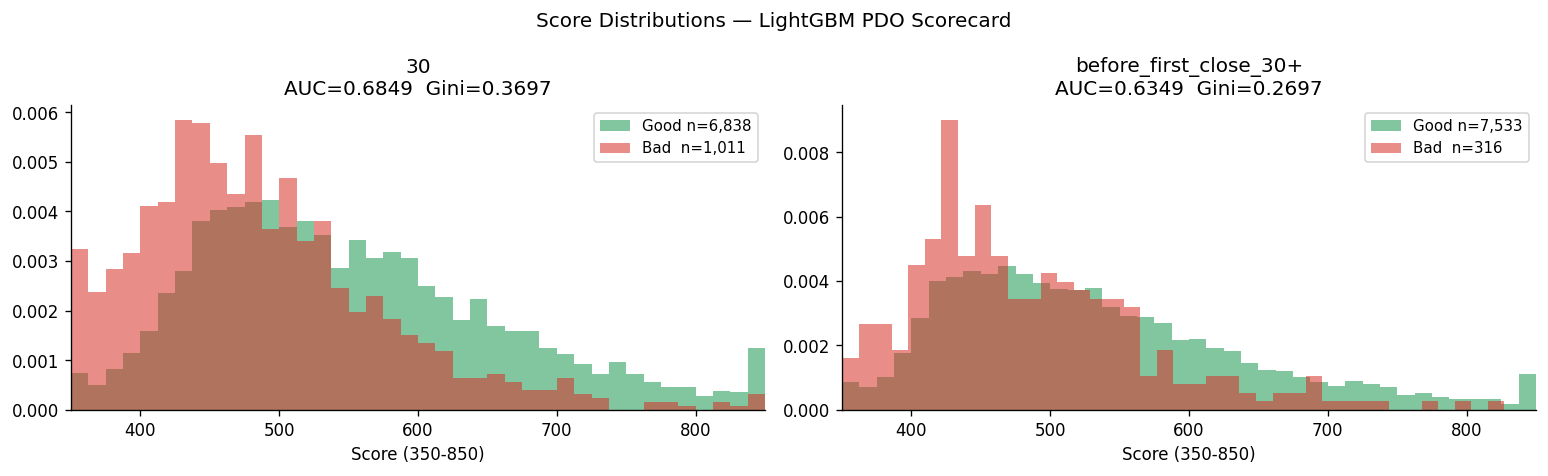

In [5]:
fig, axes = plt.subplots(1, len(all_res), figsize=(6.5*len(all_res), 4))
if len(all_res)==1: axes=[axes]
for ax, (target, res) in zip(axes, all_res.items()):
    s, y = res['s_te'], res['y_te']
    auc = metrics.roc_auc_score(y, -s)
    ax.hist(s[y==0], bins=40, alpha=0.55, density=True, color='#1a9850',
            label=f'Good n={int((y==0).sum()):,}')
    ax.hist(s[y==1], bins=40, alpha=0.55, density=True, color='#d73027',
            label=f'Bad  n={int((y==1).sum()):,}')
    ax.set_title(f'{target}\nAUC={auc:.4f}  Gini={2*auc-1:.4f}')
    ax.set_xlabel('Score (350-850)'); ax.set_xlim(350,850); ax.legend(fontsize=9)
    ax.spines[['top','right']].set_visible(False)
plt.suptitle('Score Distributions — LightGBM PDO Scorecard'); plt.tight_layout(); plt.show()

## 4. Score band шинжилгээ


30:
                 Band  Count  Pct %  Bad Rate %
       Poor (350-450)   1575  20.07       25.33
       Fair (450-550)   3019  38.46       13.75
       Good (550-650)   1983  25.26        7.26
  Very Good (650-750)    881  11.22        4.65
Exceptional (750-850)    301   3.83        2.99

before_first_close_30+:
                 Band  Count  Pct %  Bad Rate %
       Poor (350-450)   1983  25.26        6.61
       Fair (450-550)   3072  39.14        4.23
       Good (550-650)   1739  22.16        2.24
  Very Good (650-750)    710   9.05        1.83
Exceptional (750-850)    253   3.22        1.19


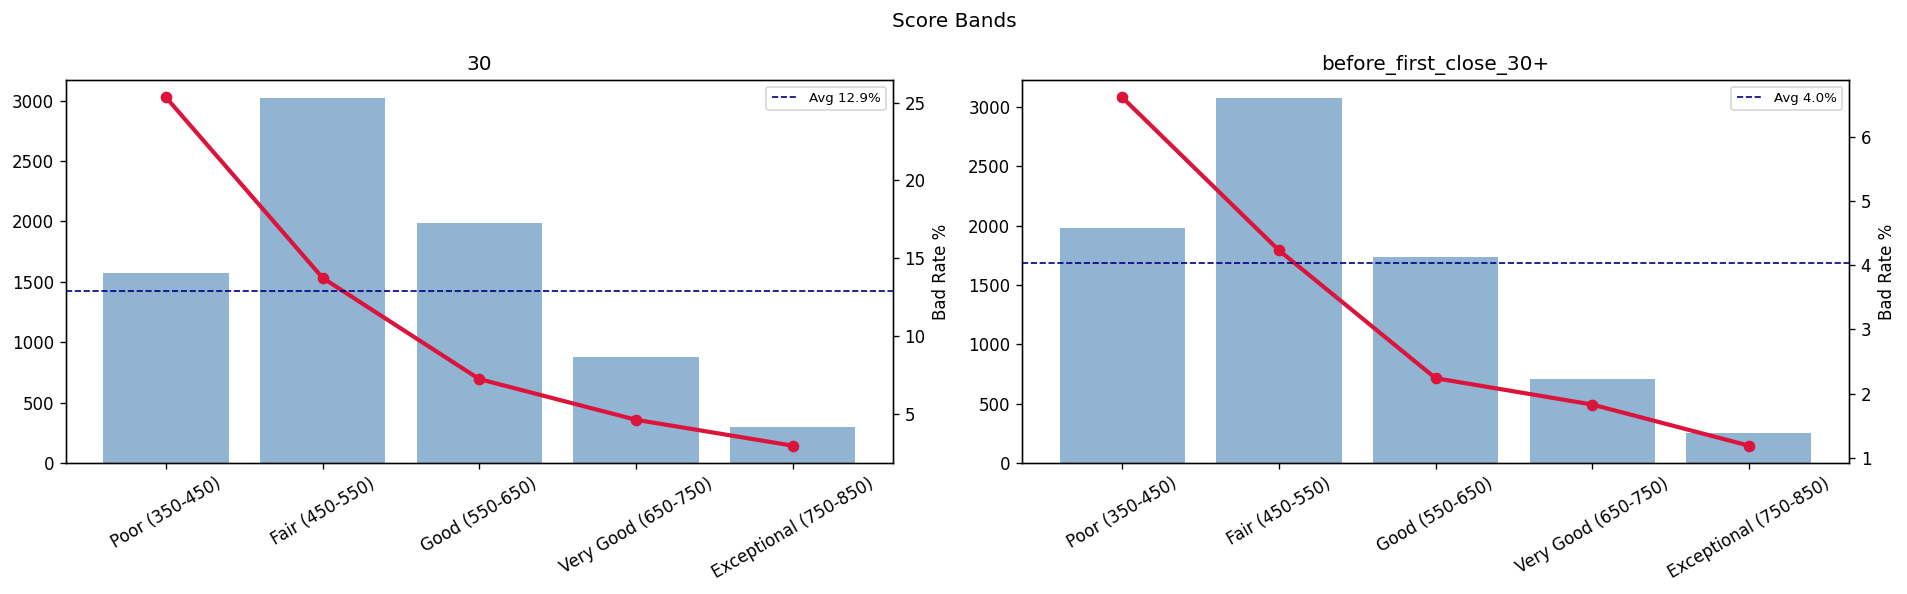

In [6]:
BAND_EDGES = [350,450,550,650,750,850]
BAND_LABELS = ['Poor','Fair','Good','Very Good','Exceptional']

fig, axes = plt.subplots(1, len(all_res), figsize=(8*len(all_res), 5))
if len(all_res)==1: axes=[axes]
for ax, (target, res) in zip(axes, all_res.items()):
    s, y = res['s_te'], res['y_te']
    band = metrics.score_band_table(s, y, BAND_EDGES, BAND_LABELS)
    ax2 = ax.twinx()
    ax.bar(band['Band'], band['Count'], color='steelblue', alpha=0.6)
    ax2.plot(band['Band'], band['Bad Rate %'], color='crimson', marker='o', lw=2.5)
    ax2.axhline(y.mean()*100, color='navy', ls='--', lw=1, label=f'Avg {y.mean()*100:.1f}%')
    ax.set_title(f'{target}'); ax.tick_params(axis='x', rotation=30)
    ax2.set_ylabel('Bad Rate %'); ax2.legend(fontsize=8)
    print(f'\n{target}:'); print(band.to_string(index=False))
plt.suptitle('Score Bands'); plt.tight_layout(); plt.show()

## 5. SHAP feature importance

LightGBM `pred_contrib=True` → таамаглал бүрийг feature тус бүрийн хувь нэмэр болгож задална.

SHAP нь модель таамаглахдаа аль хувьсагчид хэр 'жинтэй' тулгуурлаж байгааг харуулна — feature importance-ийн хамгийн найдвартай хэлбэр.

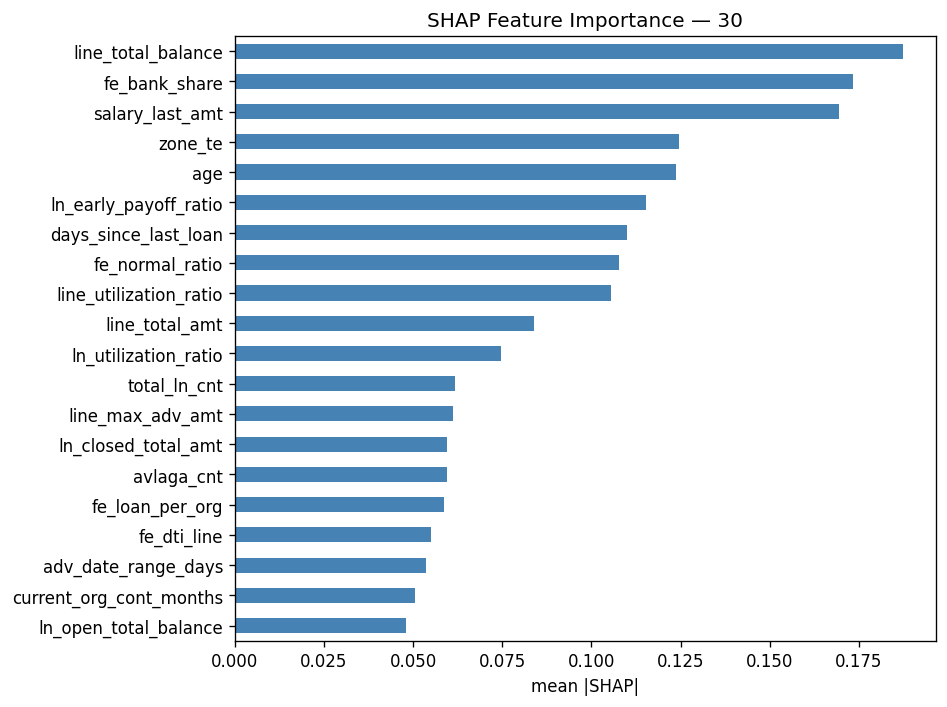

30 top5: ['line_total_balance', 'fe_bank_share', 'salary_last_amt', 'zone_te', 'age']


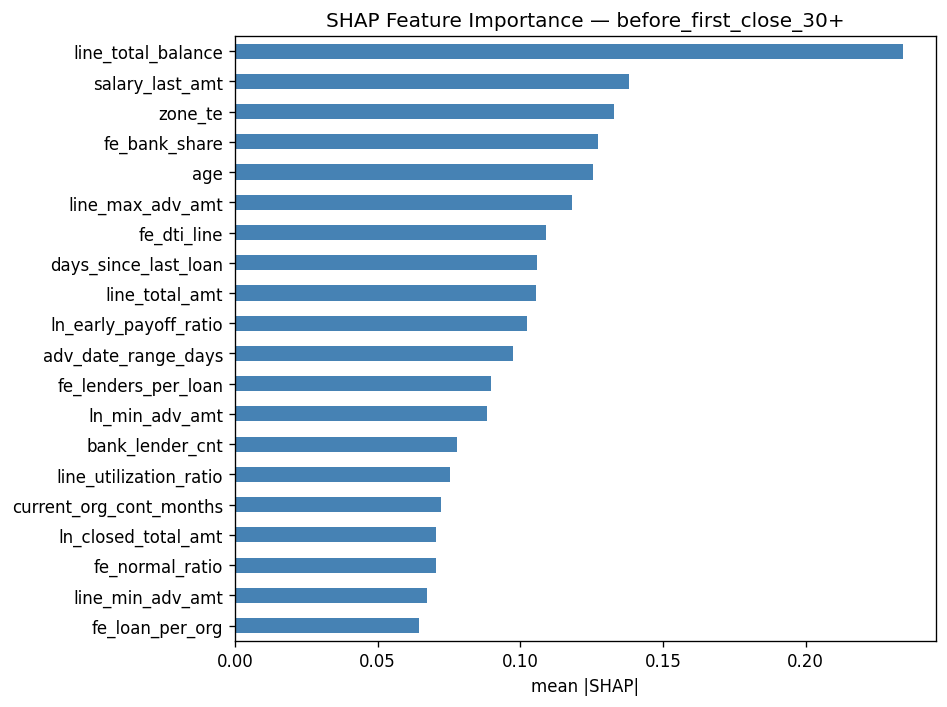

before_first_close_30+ top5: ['line_total_balance', 'salary_last_amt', 'zone_te', 'fe_bank_share', 'age']


In [7]:
for target, res in all_res.items():
    shap_vals = res['model'].predict(res['X_te'], pred_contrib=True)
    shap_feats = shap_vals[:, :-1]
    mean_abs = np.abs(shap_feats).mean(axis=0)
    fi = pd.Series(mean_abs, index=res['feats']).sort_values(ascending=False)
    res['feat_importance'] = fi

    fig, ax = plt.subplots(figsize=(8, 6))
    fi.head(20)[::-1].plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'SHAP Feature Importance — {target}')
    ax.set_xlabel('mean |SHAP|'); plt.tight_layout(); plt.show()
    print(f'{target} top5: {list(fi.head(5).index)}')

## 6. IV — Optimal Binning (monotone)

`OptimalBinning(monotonic_trend="auto_asc_desc")` нь bin бүрийн WoE/bad-rate-г монотон болгоно.
IV босго: <0.02 хэрэггүй · 0.02-0.1 сул · 0.1-0.3 дунд · >0.3 хүчтэй.

Хамгийн чухал хувьсагчдын IV-г монотон binning-ээр баталгаажуулна — SHAP болон IV хоёр нийцэж байвал тухайн хувьсагчид итгэх итгэл нэмэгдэнэ.

In [8]:
from optbinning import OptimalBinning

def iv_label(iv):
    if iv < 0.02: return 'Useless'
    if iv < 0.1:  return 'Weak'
    if iv < 0.3:  return 'Medium'
    return 'Strong'

def get_iv(binner):
    bt = binner.binning_table.build()
    iv_col = bt['IV']
    mask = ~iv_col.index.isin(['Special','Missing','Totals'])
    return float(pd.to_numeric(iv_col[mask], errors='coerce').sum())

iv_results = {}
for target, res in all_res.items():
    fi = res['feat_importance']
    top_feats = [f for f in fi.head(8).index if f in res['X_tr'].columns]
    feat_iv = {}
    for feat in top_feats:
        x = np.array(res['X_tr'][feat], dtype=float)
        valid = x != -999
        if valid.sum() < 100: continue
        try:
            ob = OptimalBinning(name=feat, dtype='numerical',
                                monotonic_trend='auto_asc_desc')
            ob.fit(x[valid], res['y_tr'][valid])
            feat_iv[feat] = get_iv(ob)
        except Exception:
            continue
    iv_results[target] = pd.Series(feat_iv).sort_values(ascending=False)
    print(f'\n=== IV (top features) — {target} ===')
    for f, v in iv_results[target].items():
        print(f'  {f:28s} IV={v:.3f}  ({iv_label(v)})')


=== IV (top features) — 30 ===
  line_total_balance           IV=0.155  (Medium)
  ln_early_payoff_ratio        IV=0.090  (Weak)
  fe_normal_ratio              IV=0.085  (Weak)
  salary_last_amt              IV=0.082  (Weak)
  fe_bank_share                IV=0.082  (Weak)
  zone_te                      IV=0.031  (Weak)
  days_since_last_loan         IV=0.019  (Useless)
  age                          IV=0.014  (Useless)



=== IV (top features) — before_first_close_30+ ===
  line_total_balance           IV=0.171  (Medium)
  line_max_adv_amt             IV=0.162  (Medium)
  fe_dti_line                  IV=0.130  (Medium)
  salary_last_amt              IV=0.090  (Weak)
  age                          IV=0.034  (Weak)
  zone_te                      IV=0.033  (Weak)
  days_since_last_loan         IV=0.021  (Weak)
  fe_bank_share                IV=0.019  (Useless)


## 7. Корреляц (өмнө/дараа) ба хувьсагч × bad rate

Зүүн: цөөлөхөөс өмнөх топ 30 IV хувьсагчийн корреляц (multicollinearity их).
Баруун: сонгосон хувьсагчдын корреляц (цэгцтэй). Дараа нь сонгосон топ хувьсагч
бүрийн bad rate decile тус бүрээр.

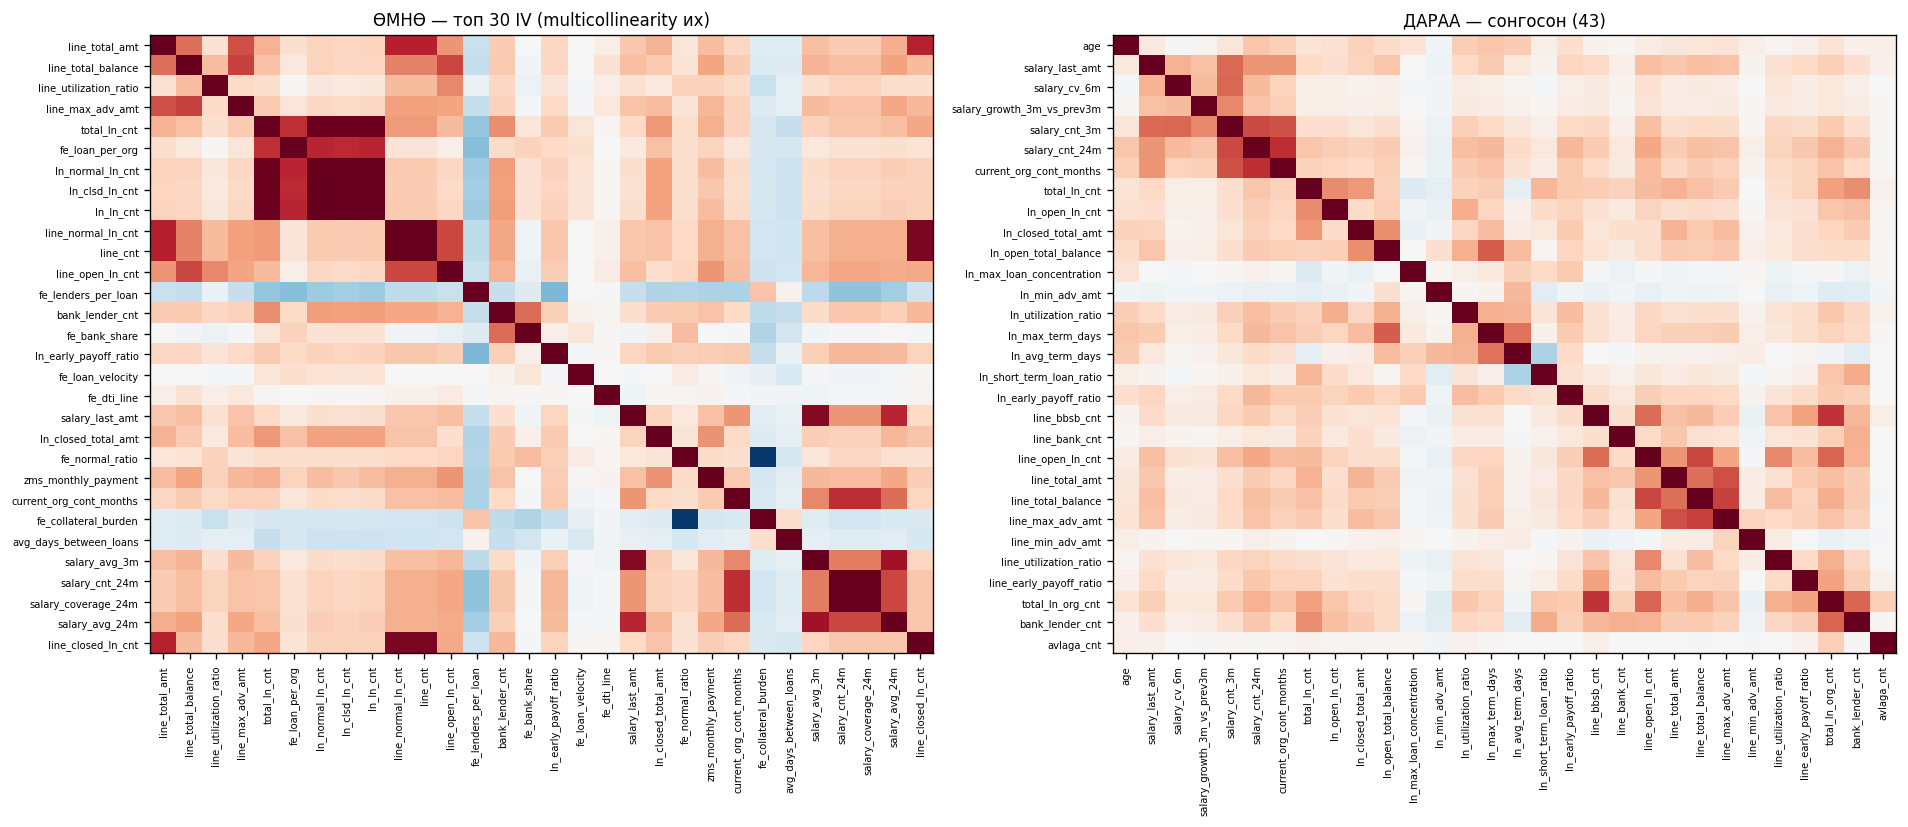

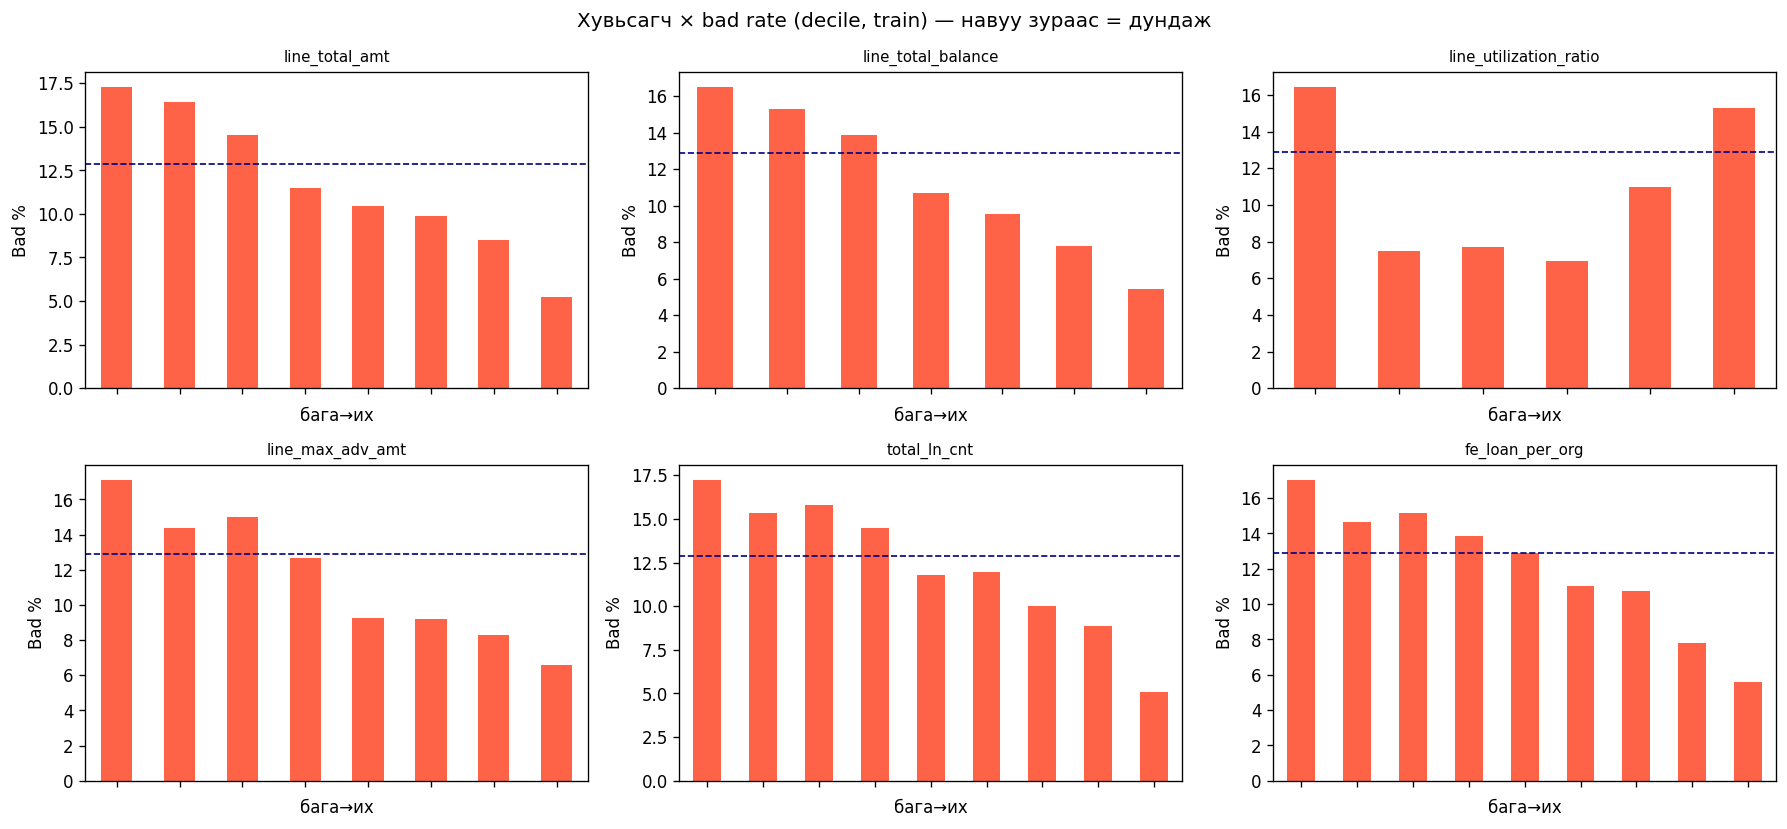

In [9]:
# Корреляц heatmap — өмнө/дараа
iv_s = pd.Series(IV_NUM).sort_values(ascending=False)
before = [c for c in iv_s.head(30).index if c in df_tr0.columns]
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
metrics.plot_corr_heatmap(df_tr0, before, axes[0], 'ӨМНӨ — топ 30 IV (multicollinearity их)')
metrics.plot_corr_heatmap(df_tr0, SEL_NUM[:30], axes[1], f'ДАРАА — сонгосон ({len(SEL_NUM)})')
plt.tight_layout(); plt.show()

# Хувьсагч × bad rate (сонгосон топ 6, train)
top6 = list(iv_s.head(6).index)
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, feat in zip(axes.ravel(), top6):
    metrics.plot_feature_badrate(df_tr0, feat, config.PRIMARY_TARGET, ax)
plt.suptitle('Хувьсагч × bad rate (decile, train) — навуу зураас = дундаж')
plt.tight_layout(); plt.show()

## Дүгнэлт

- **Test гүйцэтгэл:** `30` дээр AUC ≈ **0.689**, Gini ≈ 0.379, KS ≈ 0.288 —
  02-ын шугаман scorecard-аас (0.672) арай илүү, учир нь LightGBM интеракцыг барина.
- **PDO scoring** нь нарийн моделийг банкны стандарт 350–850 оноо болгон,
  ойлгомжтой, хэрэгжүүлэхэд бэлэн болгоно.
- **SHAP ба IV нийцэж** байгаа нь гол хувьсагчид (зээлийн дүн/үлдэгдэл, хугацаа
  хэтрэлт, лендер тоо) тогтвортой эрсдэлийн дохио болохыг батална.
- **Дараагийн боломж:** AUC > 0.70-д хүрэхийн тулд илүү feature, calibration
  (Platt/Isotonic), out-of-time валидаци нэмэх.